## Configuración Global

In [1]:
# ==========================================
# 1. CONFIGURACIÓN Y LIBRERÍAS
# ==========================================
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "holidays", "-q"])

import holidays
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sqlite3
import os

# Configuración de visualización
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Reproducibilidad (Punto 5 de la rúbrica)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Rutas relativas (Evita rutas absolutas como C:/Users/...)
PATH_DB = os.path.join('data', 'data_accidentes.sqlite3')

## Carga y construcción del dataset

In [2]:
def construir_dataset_maestro(path_db):
    if not os.path.exists(path_db):
        raise FileNotFoundError(f"No se encontró la base de datos en: {path_db}")

    con = sqlite3.connect(path_db)
    # CARGA ORIGINAL (Estas son las que te faltaban afuera)
    accidentes_orig = pd.read_sql('SELECT * FROM accidentes', con, parse_dates=['TW'])
    clima_orig = pd.read_sql('SELECT * FROM clima', con, parse_dates=['TW'])
    raw_orig = pd.read_sql('SELECT * FROM raw_accidentes', con, parse_dates=['TW'])
    con.close()
    
    # --- Tu lógica de estandarización ---
    # (Usa copias para no alterar las originales que vas a devolver)
    acc = accidentes_orig.copy()
    cli = clima_orig.copy()
    
    acc['TW'] = acc['TW'].dt.floor('h')
    cli['TW'] = cli['TW'].dt.floor('h')
    acc['BARRIO'] = acc['BARRIO'].str.strip().str.upper()
    cli['BARRIO'] = cli['BARRIO'].str.strip().str.upper()
    
    positivos = acc[['TW', 'BARRIO']].drop_duplicates()
    positivos['target'] = 1
    
    df_final = pd.merge(cli, positivos, on=['TW', 'BARRIO'], how='left')
    df_final['target'] = df_final['target'].fillna(0).astype(int)
    
    # CAMBIO AQUÍ: Devolvemos 4 cosas en lugar de 1
    return df_final, accidentes_orig, clima_orig, raw_orig

    # Ahora recibimos las 4 variables
df, accidentes, clima, raw = construir_dataset_maestro(PATH_DB)

## 2. Calidad de Datos
En esta sección se verifica la integridad de las tres tablas (`accidentes`, `clima`, `raw_accidentes`) y la consistencia del dataset final.

**Consistencia de Llaves (TW y BARRIO)**

In [3]:
# =============================================================================
# 1. CONSISTENCIA DE FORMATO EN TW
# =============================================================================

print("=" * 60)
print("1. CONSISTENCIA DE TW (marca temporal)")
print("=" * 60)

for nombre, tabla in [('accidentes', accidentes), ('clima', clima), ('raw', raw)]:
    print(f"\n[{nombre}]")
    print(f"  Tipo de TW:       {tabla['TW'].dtype}")
    print(f"  Rango:            {tabla['TW'].min()} → {tabla['TW'].max()}")
    print(f"  ¿Truncada a hora? {(tabla['TW'].dt.minute == 0).all() and (tabla['TW'].dt.second == 0).all()}")
    print(f"  Nulos en TW:      {tabla['TW'].isnull().sum()}")

# =============================================================================
# 2. CONSISTENCIA DE NOMBRES DE BARRIO
# =============================================================================

print("\n" + "=" * 60)
print("2. CONSISTENCIA DE NOMBRES DE BARRIO")
print("=" * 60)

barrios_accidentes = set(accidentes['BARRIO'].unique())
barrios_clima      = set(clima['BARRIO'].unique())

print(f"\nBarrios únicos en accidentes: {len(barrios_accidentes)}")
print(f"Barrios únicos en clima:      {len(barrios_clima)}")

# Barrios en accidentes que NO están en clima (no van a cruzar)
solo_en_accidentes = barrios_accidentes - barrios_clima
solo_en_clima      = barrios_clima - barrios_accidentes

print(f"\nBarrios en accidentes que NO están en clima: {len(solo_en_accidentes)}")
if solo_en_accidentes:
    print("  →", sorted(solo_en_accidentes)[:20])

print(f"\nBarrios en clima que NO están en accidentes: {len(solo_en_clima)}")
if solo_en_clima:
    print("  →", sorted(solo_en_clima)[:20])

# Posibles inconsistencias por mayúsculas / espacios antes de estandarizar
barrios_raw_acc = set(accidentes['BARRIO'].str.strip().str.upper().unique())
barrios_raw_cli = set(clima['BARRIO'].str.strip().str.upper().unique())
mejora = len(barrios_raw_acc & barrios_raw_cli) - len(barrios_accidentes & barrios_clima)
print(f"\nBarrios que se recuperan al estandarizar (strip + upper): {mejora}")

1. CONSISTENCIA DE TW (marca temporal)

[accidentes]
  Tipo de TW:       datetime64[ns]
  Rango:            2017-01-01 00:00:00 → 2019-12-31 23:00:00
  ¿Truncada a hora? True
  Nulos en TW:      0

[clima]
  Tipo de TW:       datetime64[ns]
  Rango:            2017-01-01 00:00:00 → 2019-12-31 23:00:00
  ¿Truncada a hora? True
  Nulos en TW:      0

[raw]
  Tipo de TW:       datetime64[ns]
  Rango:            2017-01-01 00:00:00 → 2019-12-31 23:00:00
  ¿Truncada a hora? True
  Nulos en TW:      0

2. CONSISTENCIA DE NOMBRES DE BARRIO

Barrios únicos en accidentes: 322
Barrios únicos en clima:      319

Barrios en accidentes que NO están en clima: 3
  → ['elastillero', 'suburbanoaguasfrias', 'yarumalito']

Barrios en clima que NO están en accidentes: 0

Barrios que se recuperan al estandarizar (strip + upper): 0


**Duplicados y Nulos**


3. DUPLICADOS

[accidentes]  Filas duplicadas (exactas): 0

[clima]  Filas duplicadas (exactas): 0

[raw]  Filas duplicadas (exactas): 0

Duplicados en (TW, BARRIO):
  accidentes: 0
  clima:      0
  df final:   0

4. VALORES FALTANTES

[accidentes] — 0 columnas con nulos:
  Sin valores faltantes.

[clima] — 13 columnas con nulos:
                     faltantes  porcentaje
windBearing            1032513       12.92
summary                 548641        6.87
icon                    548641        6.87
precipIntensity         547401        6.85
precipProbability       547401        6.85
windSpeed                32793        0.41
cloudCover                7950        0.10
uvIndex                   4280        0.05
visibility                4290        0.05
temperature                610        0.01
apparentTemperature        610        0.01
humidity                   915        0.01
dewPoint                   305        0.00

[raw_accidentes] — 3 columnas con nulos:
            faltantes 

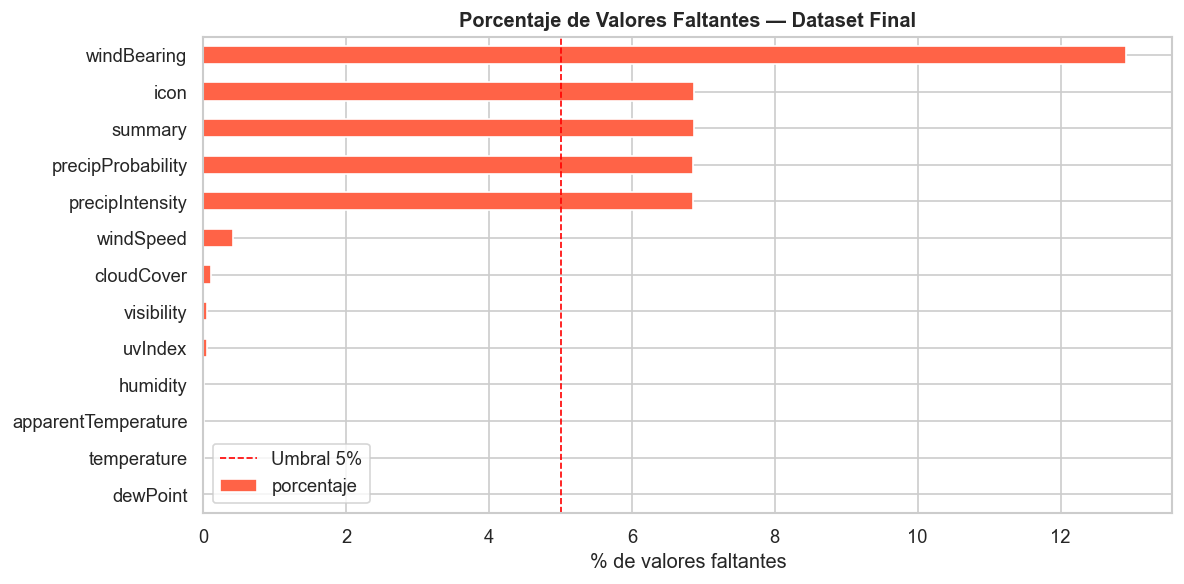

In [4]:
# =============================================================================
# 3. DUPLICADOS
# =============================================================================

print("\n" + "=" * 60)
print("3. DUPLICADOS")
print("=" * 60)

# Duplicados exactos (todas las columnas)
for nombre, tabla in [('accidentes', accidentes), ('clima', clima), ('raw', raw)]:
    dup_total = tabla.duplicated().sum()
    print(f"\n[{nombre}]  Filas duplicadas (exactas): {dup_total}")

# Duplicados en llave de cruce
dup_acc  = accidentes.duplicated(subset=['TW', 'BARRIO']).sum()
dup_cli  = clima.duplicated(subset=['TW', 'BARRIO']).sum()
dup_df   = df.duplicated(subset=['TW', 'BARRIO']).sum()

print(f"\nDuplicados en (TW, BARRIO):")
print(f"  accidentes: {dup_acc}")
print(f"  clima:      {dup_cli}")
print(f"  df final:   {dup_df}")

# Si hay duplicados en clima los eliminamos
if dup_cli > 0:
    clima = clima.drop_duplicates(subset=['TW', 'BARRIO'])
    print(f"  → Duplicados en clima eliminados. Nuevo tamaño: {len(clima)}")

# =============================================================================
# 4. VALORES FALTANTES
# =============================================================================

print("\n" + "=" * 60)
print("4. VALORES FALTANTES")
print("=" * 60)

def reporte_nulos(tabla, nombre):
    nulos = tabla.isnull().sum()
    pct   = (nulos / len(tabla) * 100).round(2)
    reporte = pd.DataFrame({'faltantes': nulos, 'porcentaje': pct})
    reporte = reporte[reporte['faltantes'] > 0].sort_values('porcentaje', ascending=False)
    print(f"\n[{nombre}] — {len(reporte)} columnas con nulos:")
    print(reporte if len(reporte) > 0 else "  Sin valores faltantes.")
    return reporte

nulos_acc = reporte_nulos(accidentes, 'accidentes')
nulos_cli = reporte_nulos(clima,      'clima')
nulos_raw = reporte_nulos(raw,        'raw_accidentes')
nulos_df  = reporte_nulos(df,         'df final')

# Visualización de nulos en el dataset final
if nulos_df is not None and len(nulos_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    nulos_df['porcentaje'].sort_values().plot(
        kind='barh', ax=ax, color='tomato', edgecolor='white')
    ax.set_title('Porcentaje de Valores Faltantes — Dataset Final', fontweight='bold')
    ax.set_xlabel('% de valores faltantes')
    ax.axvline(5, color='red', linestyle='--', linewidth=1, label='Umbral 5%')
    ax.legend()
    plt.tight_layout()
    plt.show()

**Análisis de Outliers**


5. VALORES ATÍPICOS EN VARIABLES CLIMÁTICAS
                       min      Q1  mediana       Q3      max  límite_inf  \
temperature          4.510  16.830  18.6100  22.5200  35.9900       8.295   
apparentTemperature  4.510  16.890  18.7100  22.6000  38.0600       8.325   
dewPoint             2.160  13.000  14.4200  15.7900  24.0400       8.815   
humidity             0.170   0.640   0.7400   0.8500   1.0000       0.325   
precipIntensity      0.000   0.000   0.0302   0.6058  20.8236      -0.909   
precipProbability    0.000   0.000   0.0600   0.2600   1.0000      -0.390   
windSpeed            0.000   0.810   1.3600   2.0900  15.2600      -1.110   
cloudCover           0.000   0.520   0.7500   0.9000   1.0000      -0.050   
uvIndex              0.000   0.000   0.0000   4.0000  14.0000      -6.000   
visibility           0.099  10.003  10.0030  15.0200  16.0930       2.478   

                     límite_sup  outliers_n  outliers_%  
temperature              31.055       912.0      

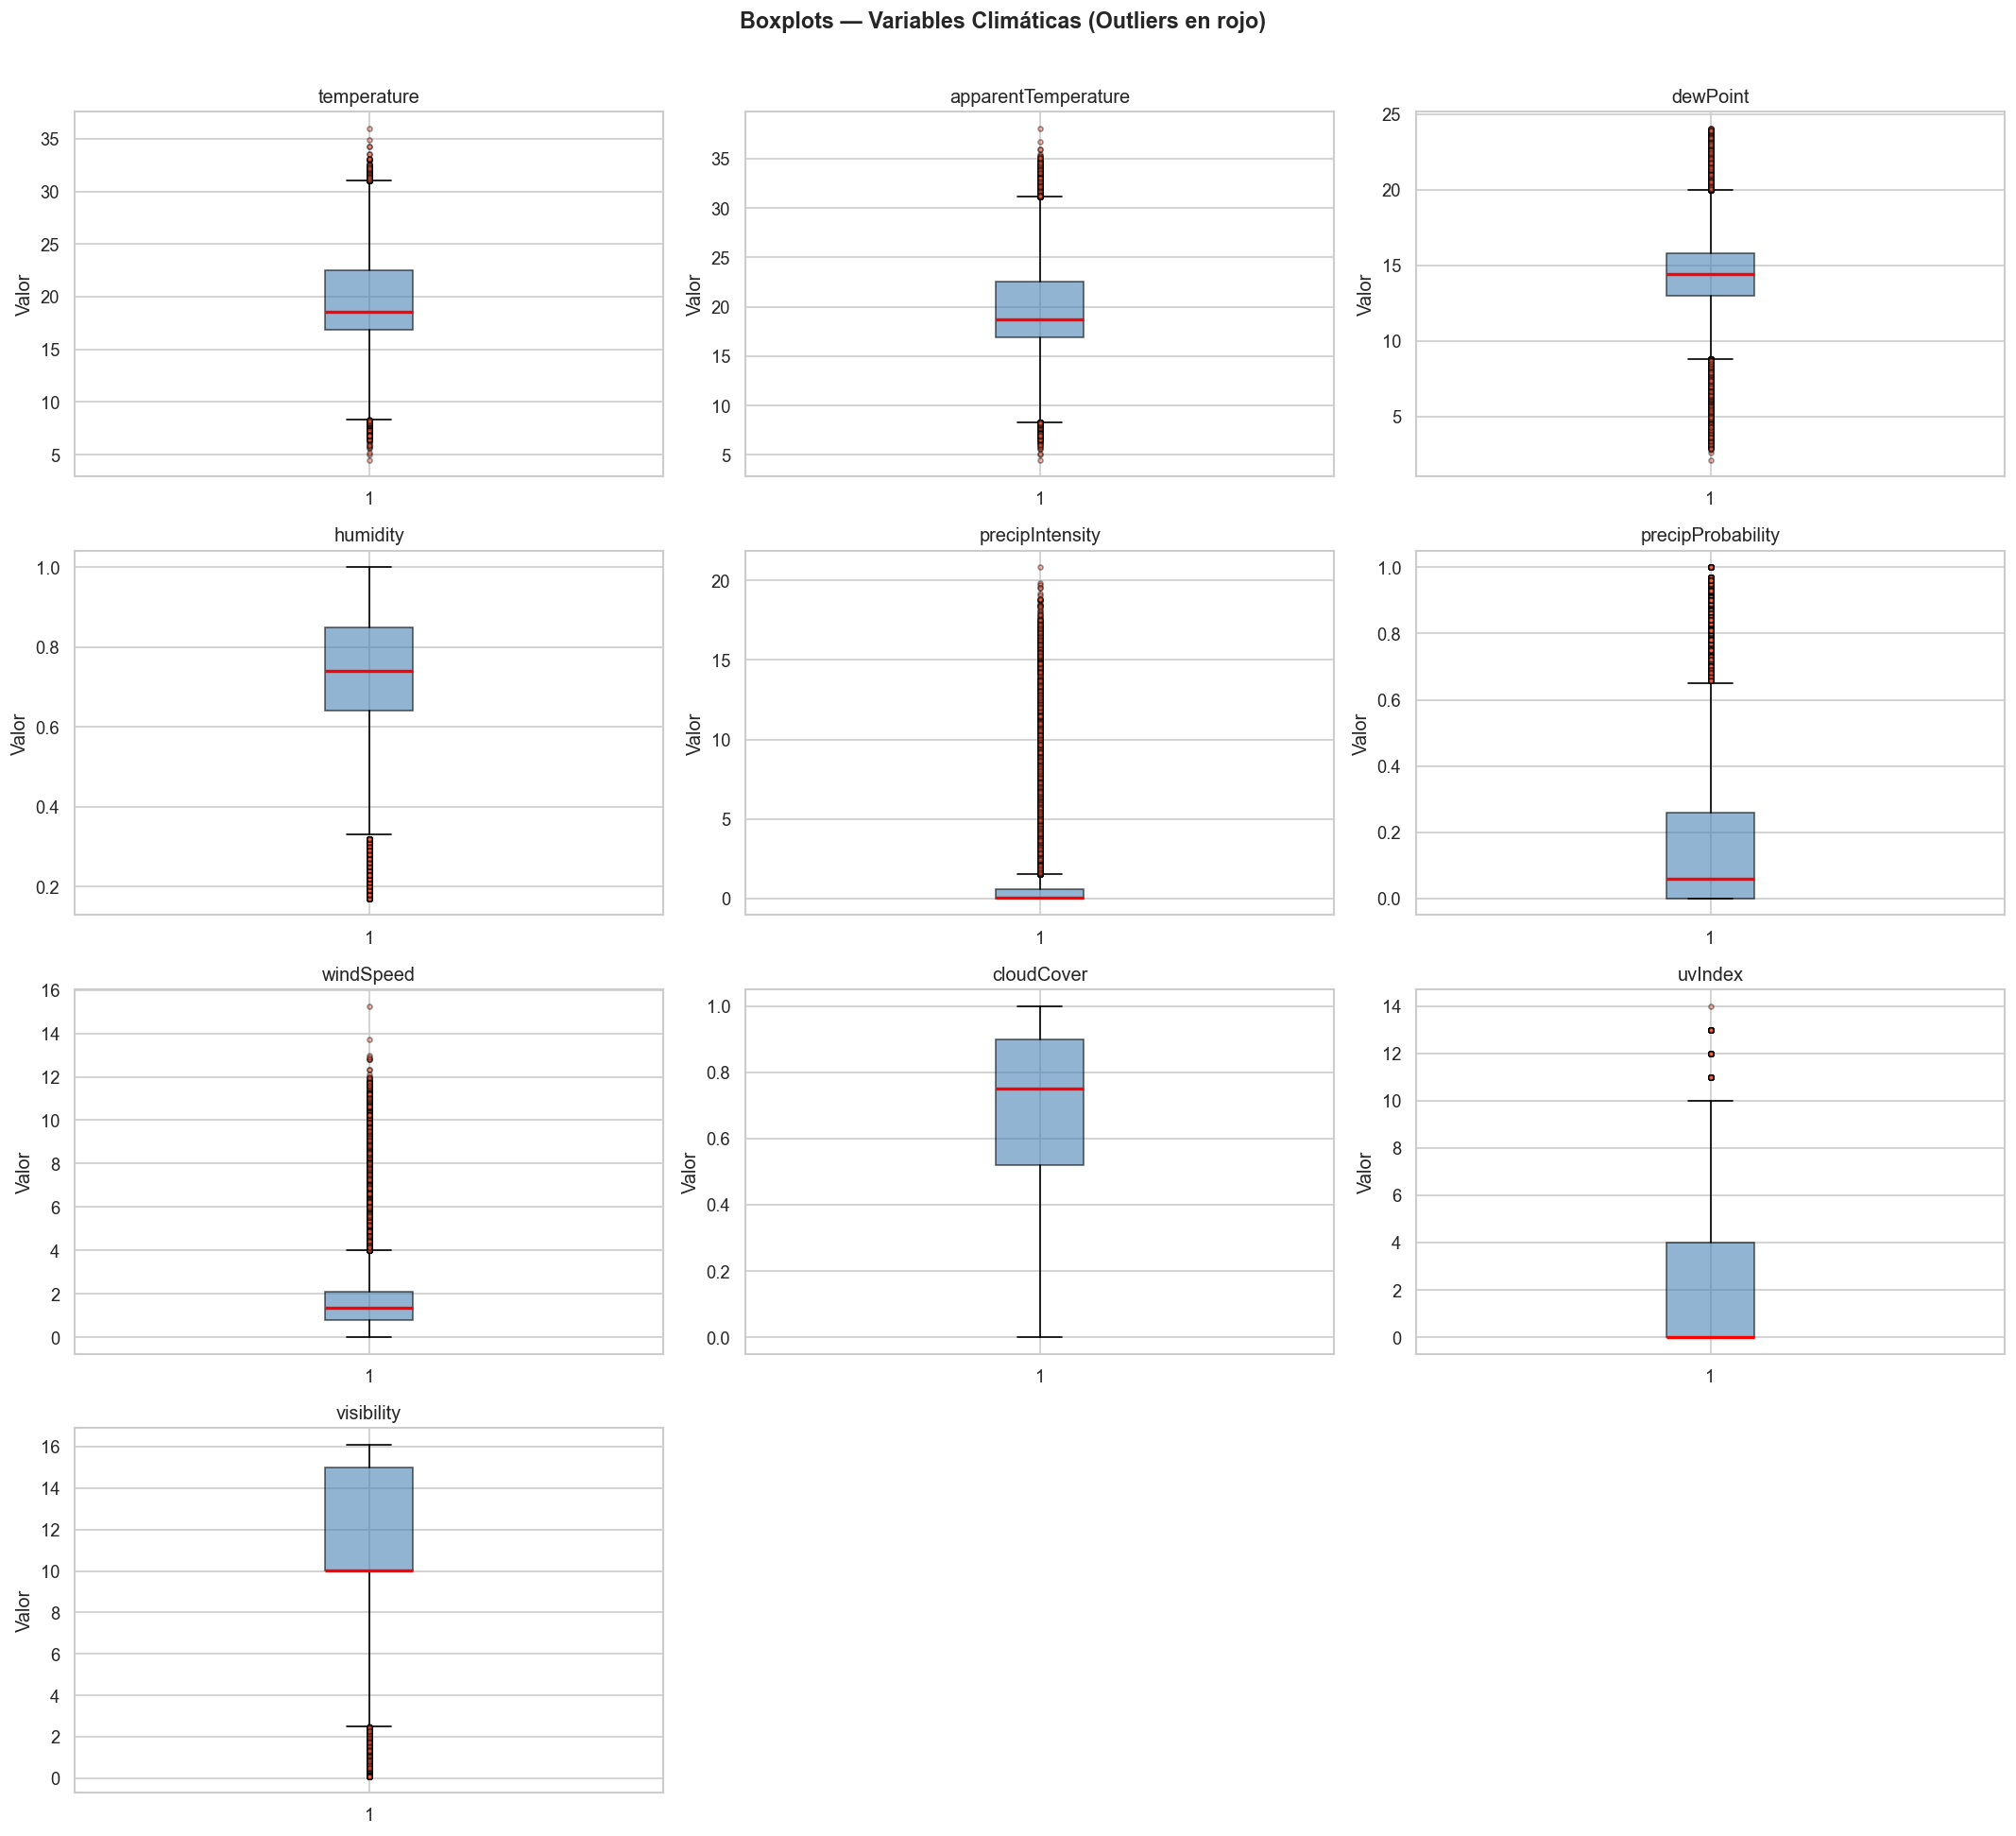

In [5]:
# =============================================================================
# 5. VALORES ATÍPICOS (OUTLIERS)
# =============================================================================

print("\n" + "=" * 60)
print("5. VALORES ATÍPICOS EN VARIABLES CLIMÁTICAS")
print("=" * 60)

vars_clima = ['temperature', 'apparentTemperature', 'dewPoint', 'humidity',
              'precipIntensity', 'precipProbability', 'windSpeed',
              'cloudCover', 'uvIndex', 'visibility']
vars_clima = [v for v in vars_clima if v in df.columns]

def detectar_outliers_iqr(serie):
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    outliers = ((serie < limite_inf) | (serie > limite_sup)).sum()
    return pd.Series({
        'min': serie.min(), 'Q1': Q1, 'mediana': serie.median(),
        'Q3': Q3, 'max': serie.max(),
        'límite_inf': round(limite_inf, 3),
        'límite_sup': round(limite_sup, 3),
        'outliers_n': outliers,
        'outliers_%': round(outliers / len(serie) * 100, 2)
    })

resumen_outliers = df[vars_clima].apply(detectar_outliers_iqr).T
print(resumen_outliers)

# Boxplots de variables climáticas para visualizar outliers
ncols = 3
nrows = (len(vars_clima) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, var in enumerate(vars_clima):
    axes[i].boxplot(df[var].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markersize=3,
                                    markerfacecolor='tomato', alpha=0.4))
    axes[i].set_title(var)
    axes[i].set_ylabel('Valor')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — Variables Climáticas (Outliers en rojo)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Validación del Cruce y Resumen**

In [6]:
# =============================================================================
# 6. VALIDACIÓN DEL CRUCE FINAL
# =============================================================================

print("\n" + "=" * 60)
print("6. VALIDACIÓN DEL CRUCE FINAL")
print("=" * 60)

# ¿Cuántos positivos del dataset final realmente cruzaron con clima?
positivos_en_df = df[df['target'] == 1]
print(f"Positivos en df final:                {len(positivos_en_df):,}")
print(f"Positivos originales en accidentes:   {len(accidentes[['TW', 'BARRIO']].drop_duplicates()):,}")

perdidos = len(accidentes[['TW', 'BARRIO']].drop_duplicates()) - len(positivos_en_df)
print(f"Positivos perdidos en el cruce:       {perdidos:,}")
if perdidos > 0:
    print("  → Revisar inconsistencias de BARRIO o TW entre las tablas.")

# Resumen final de decisiones tomadas
print("\n" + "=" * 60)
print("RESUMEN DE DECISIONES DE CALIDAD")
print("=" * 60)
print("""
  1. TW estandarizado a hora exacta con dt.floor('h') en todas las tablas.
  2. BARRIO estandarizado con strip() + upper() para evitar discrepancias.
  3. Duplicados en llave (TW, BARRIO) eliminados de clima si los hubiera.
  4. Valores faltantes identificados por columna y porcentaje.
  5. Outliers detectados con método IQR — se mantienen para el modelo
     basado en árboles (Random Forest, Gradient Boosting) que son robustos
     a outliers; se revisará en feature engineering si se usa regresión logística.
  6. Positivos perdidos en el cruce verificados — indica si hay barrios
     en accidentes que no tienen cobertura climática.
""")


6. VALIDACIÓN DEL CRUCE FINAL
Positivos en df final:                120,475
Positivos originales en accidentes:   120,587
Positivos perdidos en el cruce:       112
  → Revisar inconsistencias de BARRIO o TW entre las tablas.

RESUMEN DE DECISIONES DE CALIDAD

  1. TW estandarizado a hora exacta con dt.floor('h') en todas las tablas.
  2. BARRIO estandarizado con strip() + upper() para evitar discrepancias.
  3. Duplicados en llave (TW, BARRIO) eliminados de clima si los hubiera.
  4. Valores faltantes identificados por columna y porcentaje.
  5. Outliers detectados con método IQR — se mantienen para el modelo
     basado en árboles (Random Forest, Gradient Boosting) que son robustos
     a outliers; se revisará en feature engineering si se usa regresión logística.
  6. Positivos perdidos en el cruce verificados — indica si hay barrios
     en accidentes que no tienen cobertura climática.



## Análisis Exploratorio 

**Temporal y Espacial**

C:\Users\USER\AppData\Local\Temp\ipykernel_16872\2213698599.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=accidentes_pos, x='hora', ax=axes[0], palette='viridis')


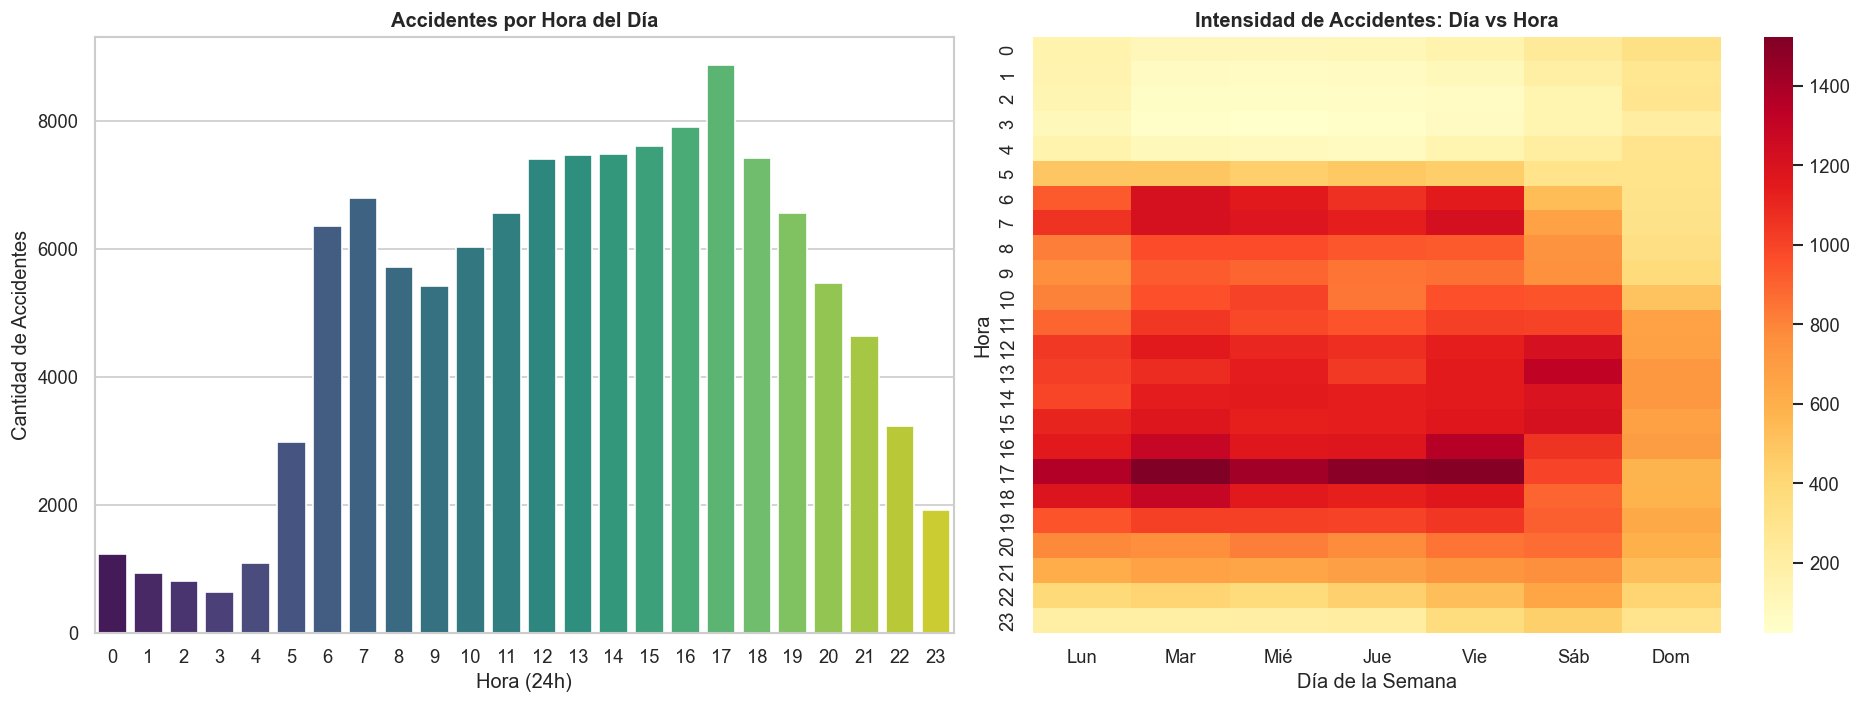

C:\Users\USER\AppData\Local\Temp\ipykernel_16872\2213698599.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_tasa['tasa'], y=top_tasa.index, palette='magma')


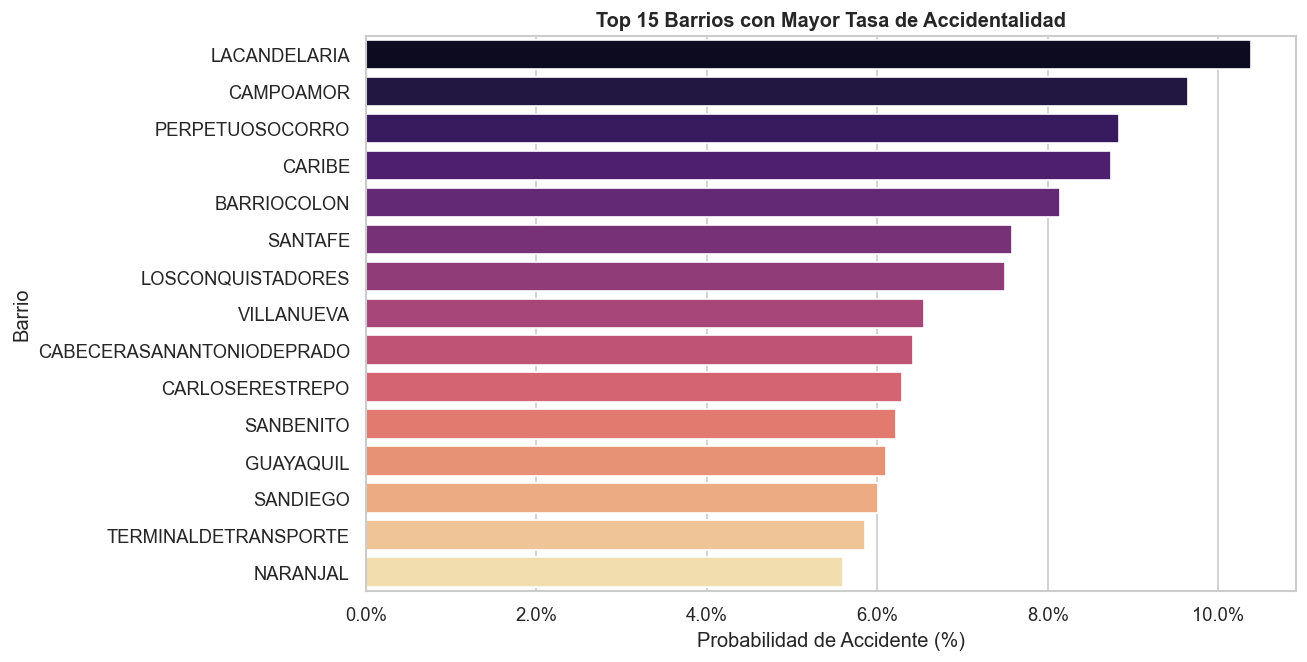

In [7]:
# ==========================================
# 3. EDA: ANÁLISIS TEMPORAL Y ESPACIAL
# ==========================================

# 3.1 Preparación de datos para visualización
accidentes_pos = df[df['target'] == 1].copy()
accidentes_pos['hora'] = accidentes_pos['TW'].dt.hour
accidentes_pos['dia_sem'] = accidentes_pos['TW'].dt.dayofweek # 0=Lunes, 6=Domingo

# --- Gráficos Temporales ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accidentes por Hora
sns.countplot(data=accidentes_pos, x='hora', ax=axes[0], palette='viridis')
axes[0].set_title('Accidentes por Hora del Día', fontweight='bold')
axes[0].set_xlabel('Hora (24h)')
axes[0].set_ylabel('Cantidad de Accidentes')

# Heatmap Hora vs Día de la Semana
dias_es = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
pivot_h_d = accidentes_pos.groupby(['hora', 'dia_sem'])['target'].count().unstack()
sns.heatmap(pivot_h_d, cmap='YlOrRd', ax=axes[1], xticklabels=dias_es)
axes[1].set_title('Intensidad de Accidentes: Día vs Hora', fontweight='bold')
axes[1].set_xlabel('Día de la Semana')
axes[1].set_ylabel('Hora')

plt.tight_layout()
plt.show()

# --- 3.2 Análisis Espacial (Tasa por Barrio) ---
# Calculamos la tasa para ver dónde es proporcionalmente más peligroso
stats_barrio = df.groupby('BARRIO')['target'].agg(['count', 'sum'])
stats_barrio.columns = ['total_horas', 'accidentes']
stats_barrio['tasa'] = stats_barrio['accidentes'] / stats_barrio['total_horas']

top_tasa = stats_barrio.sort_values('tasa', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_tasa['tasa'], y=top_tasa.index, palette='magma')
plt.gca().xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.title('Top 15 Barrios con Mayor Tasa de Accidentalidad', fontweight='bold')
plt.xlabel('Probabilidad de Accidente (%)')
plt.ylabel('Barrio')
plt.show()

**Análisis Exploratorio- Clima**

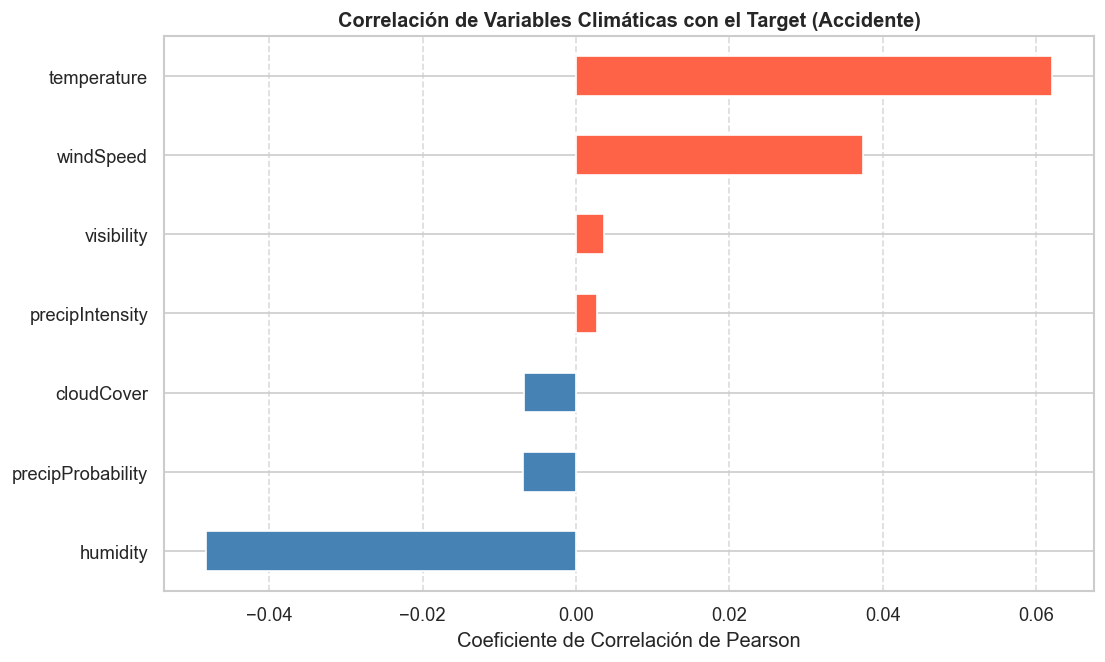

C:\Users\USER\AppData\Local\Temp\ipykernel_16872\1130256959.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y='humidity', ax=axes[0], palette='Set2')
C:\Users\USER\AppData\Local\Temp\ipykernel_16872\1130256959.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Sin Accidente', 'Con Accidente'])
C:\Users\USER\AppData\Local\Temp\ipykernel_16872\1130256959.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y='precipIntensity', ax=axes[1], palette='Set2')
C:\Users\USER\AppData\Local\Temp\ipykernel_16872\1130256959.py:33: UserWarning: se

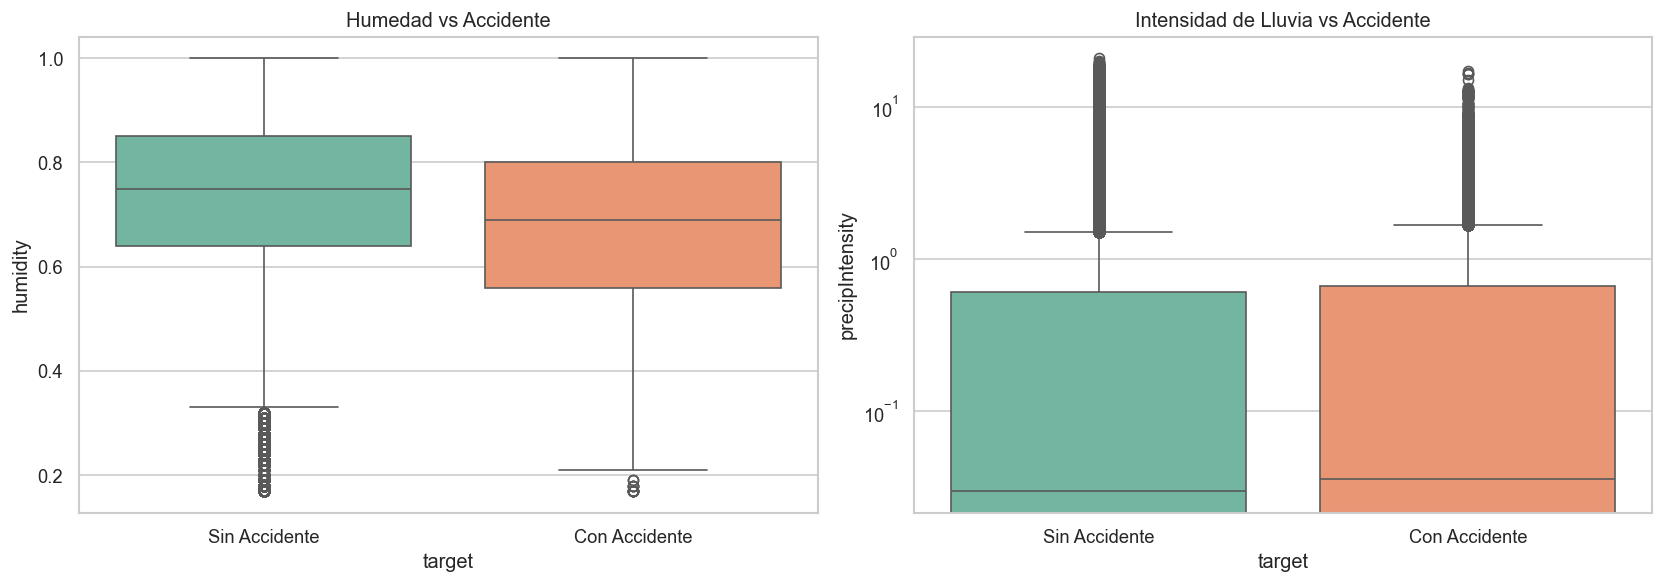

Promedio de variables climáticas según presencia de accidente:


,temperature,humidity,precipIntensity,precipProbability,windSpeed,visibility,cloudCover
target,,,,,,,
0,19.624997,0.735288,0.475840,0.159777,1.576782,11.316265,0.722608
1,21.535629,0.673776,0.495942,0.147410,1.963154,11.417221,0.711025


In [8]:
# ==========================================
# 4. EDA: ANÁLISIS CLIMÁTICO
# ==========================================

# 4.1 Selección de variables climáticas
vars_clima = ['temperature', 'humidity', 'precipIntensity', 'precipProbability',
              'windSpeed', 'visibility', 'cloudCover', 'pressure']

# Asegurar que solo usamos las que están en el DF
vars_clima = [v for v in vars_clima if v in df.columns]

# --- Gráfico de Correlación ---
plt.figure(figsize=(10, 6))
correlaciones = df[vars_clima + ['target']].corr()['target'].drop('target').sort_values()
colores = ['tomato' if c > 0 else 'steelblue' for c in correlaciones]

correlaciones.plot(kind='barh', color=colores, edgecolor='white')
plt.title('Correlación de Variables Climáticas con el Target (Accidente)', fontweight='bold')
plt.xlabel('Coeficiente de Correlación de Pearson')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# --- Análisis de Distribución (Boxplots) ---
# Vamos a ver cómo cambia la humedad y la lluvia ante un accidente
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='target', y='humidity', ax=axes[0], palette='Set2')
axes[0].set_title('Humedad vs Accidente')
axes[0].set_xticklabels(['Sin Accidente', 'Con Accidente'])

sns.boxplot(data=df, x='target', y='precipIntensity', ax=axes[1], palette='Set2')
axes[1].set_title('Intensidad de Lluvia vs Accidente')
axes[1].set_xticklabels(['Sin Accidente', 'Con Accidente'])
axes[1].set_yscale('log') # Escala logarítmica para ver mejor la lluvia

plt.tight_layout()
plt.show()

# Resumen Estadístico
print("Promedio de variables climáticas según presencia de accidente:")
display(df.groupby('target')[vars_clima].mean())

**Accidentes por mes**

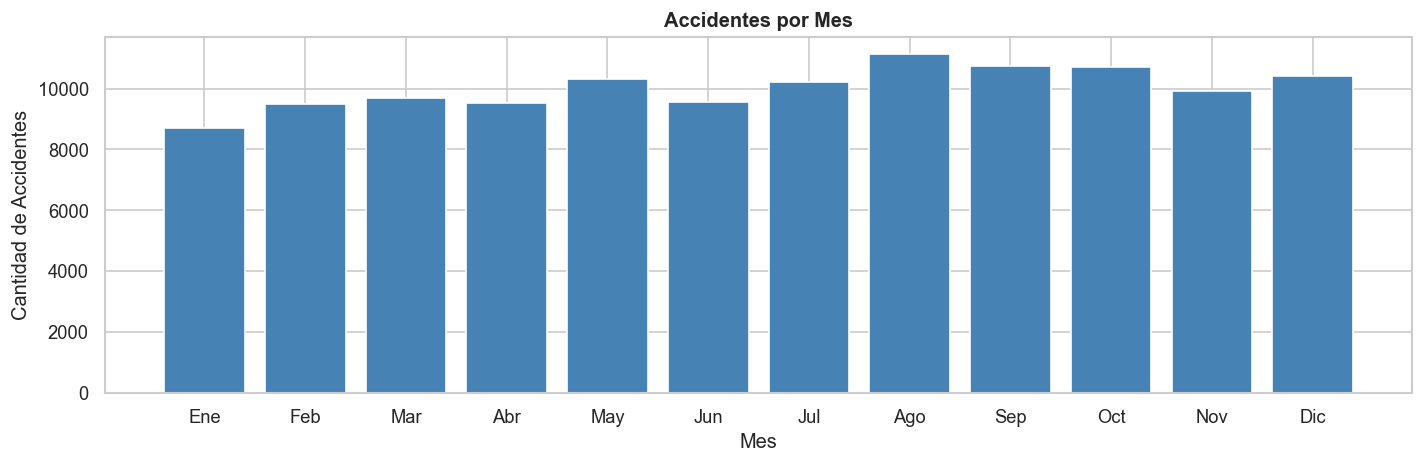

Mes con mas accidentes:   Ago (11,158)
Mes con menos accidentes: Ene (8,695)


In [9]:
# ==========================================
#  ACCIDENTES POR MES
# ==========================================

accidentes_pos = df[df['target'] == 1].copy()
accidentes_pos['mes'] = accidentes_pos['TW'].dt.month

meses_es = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
            7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}

conteo_mes = accidentes_pos.groupby('mes')['target'].count()

plt.figure(figsize=(12, 4))
plt.bar(conteo_mes.index, conteo_mes.values, color='steelblue', edgecolor='white')
plt.xticks(list(meses_es.keys()), list(meses_es.values()))
plt.title('Accidentes por Mes', fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Cantidad de Accidentes')
plt.tight_layout()
plt.show()

mes_pico = meses_es[conteo_mes.idxmax()]
mes_bajo = meses_es[conteo_mes.idxmin()]
print(f"Mes con mas accidentes:   {mes_pico} ({conteo_mes.max():,})")
print(f"Mes con menos accidentes: {mes_bajo} ({conteo_mes.min():,})")

**Analisis desde raw_accidentes**

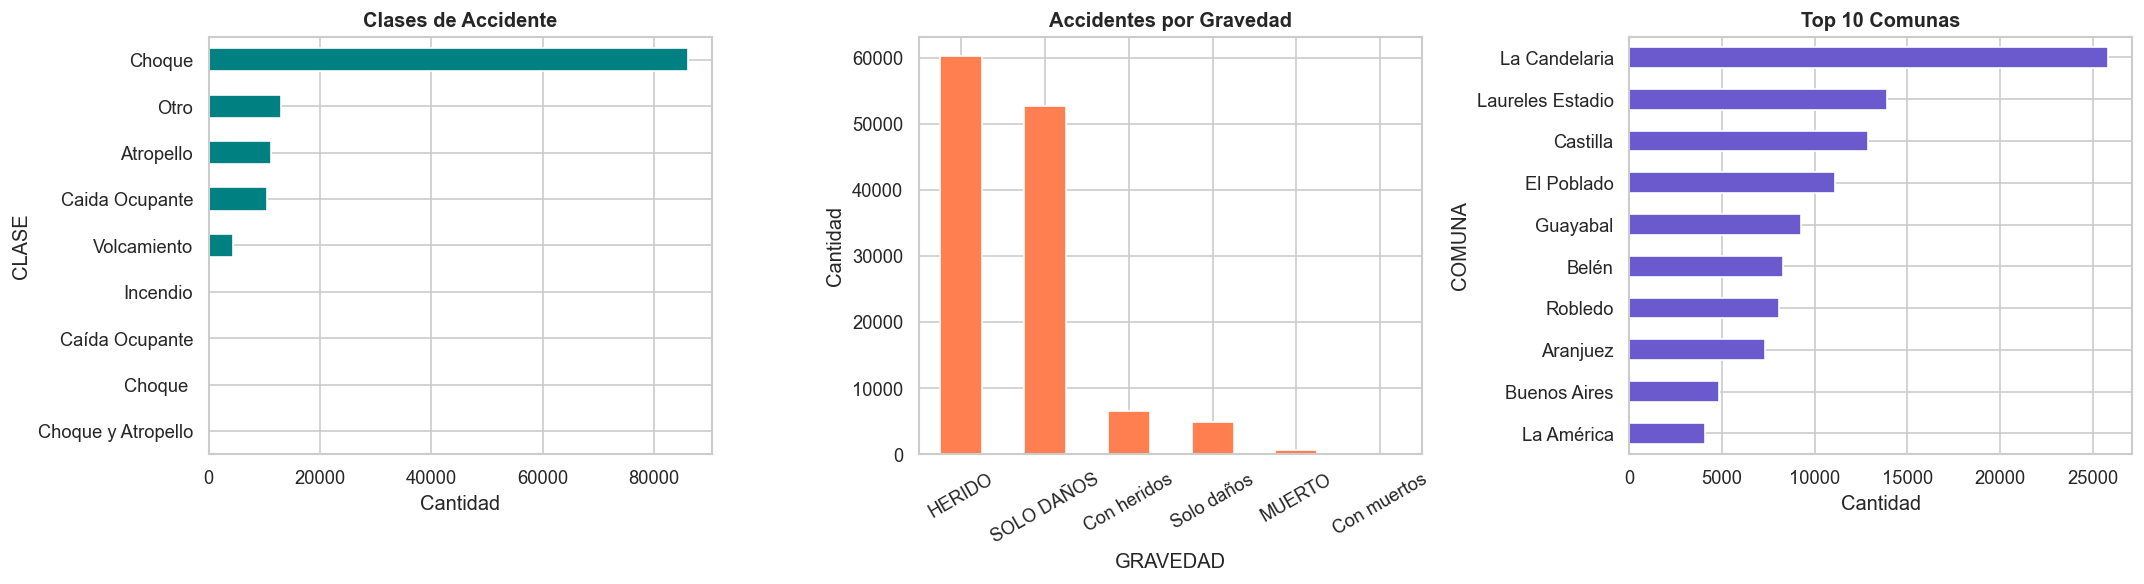

Clases mas frecuentes:
CLASE
Choque                86065
Otro                  12947
Atropello             11199
Caida Ocupante        10532
Volcamiento            4342
Incendio                 19
Caída Ocupante           14
Choque                    3
Choque y Atropello        1

Gravedad mas comun: HERIDO (60,162 casos)
Comuna con mas accidentes: La Candelaria (25,844 casos)


In [10]:
# ==========================================
# 5.2 ANALISIS DESDE raw_accidentes
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Clase de accidente
conteo_clase = raw['CLASE'].value_counts().head(10)
conteo_clase.plot(kind='barh', ax=axes[0], color='teal', edgecolor='white')
axes[0].set_title('Clases de Accidente', fontweight='bold')
axes[0].set_xlabel('Cantidad')
axes[0].invert_yaxis()

# Gravedad
conteo_grav = raw['GRAVEDAD'].value_counts()
conteo_grav.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white', rot=30)
axes[1].set_title('Accidentes por Gravedad', fontweight='bold')
axes[1].set_ylabel('Cantidad')

# Top comunas
conteo_comuna = raw['COMUNA'].value_counts().head(10)
conteo_comuna.plot(kind='barh', ax=axes[2], color='slateblue', edgecolor='white')
axes[2].set_title('Top 10 Comunas', fontweight='bold')
axes[2].set_xlabel('Cantidad')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

print("Clases mas frecuentes:")
print(conteo_clase.to_string())
print(f"\nGravedad mas comun: {conteo_grav.idxmax()} ({conteo_grav.max():,} casos)")
print(f"Comuna con mas accidentes: {conteo_comuna.idxmax()} ({conteo_comuna.max():,} casos)")

**Desbalance de clases**

Clase positiva (con accidente):    0.0151  (1.51%)
Clase negativa (sin accidente):    0.9849  (98.49%)
Ratio de desbalance: 1:65.3  (1 positivo por cada 65.3 negativos)


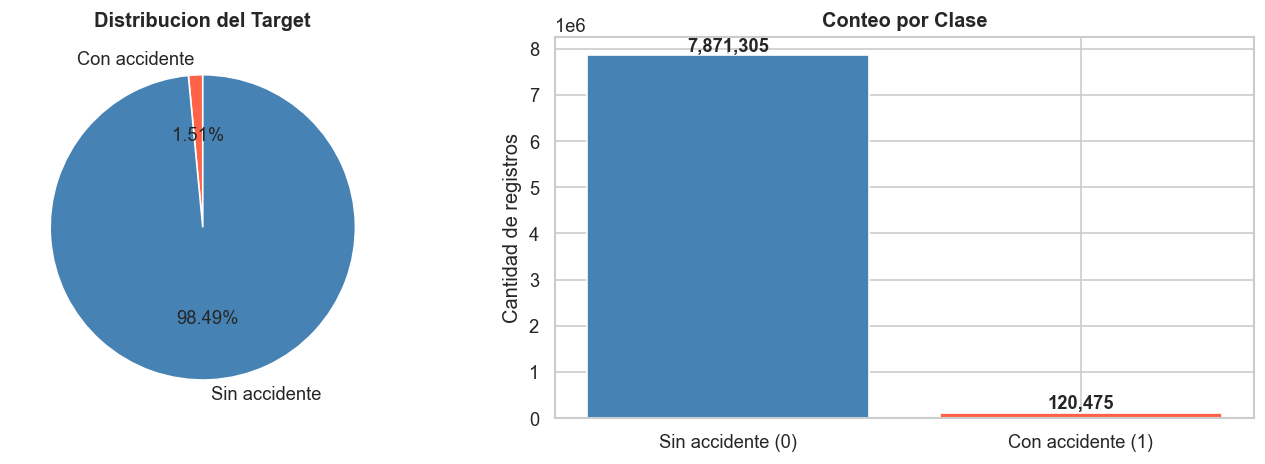


Conclusion: El desbalance marcado justifica:
  - No usar accuracy como metrica principal.
  - Aplicar estrategias de balanceo (SMOTE, class_weight, undersampling).
  - Evaluar con F1-Score, ROC-AUC y PR-AUC.



In [11]:
# ==========================================
# 5.3 DESBALANCE DE CLASES
# ==========================================

prop_pos = df['target'].mean()
prop_neg = 1 - prop_pos
ratio    = prop_neg / prop_pos

print(f"Clase positiva (con accidente):    {prop_pos:.4f}  ({prop_pos*100:.2f}%)")
print(f"Clase negativa (sin accidente):    {prop_neg:.4f}  ({prop_neg*100:.2f}%)")
print(f"Ratio de desbalance: 1:{ratio:.1f}  (1 positivo por cada {ratio:.1f} negativos)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Grafico de torta
axes[0].pie([prop_pos, prop_neg],
            labels=['Con accidente', 'Sin accidente'],
            autopct='%1.2f%%',
            colors=['tomato', 'steelblue'],
            startangle=90)
axes[0].set_title('Distribucion del Target', fontweight='bold')

# Barras de conteo
conteos = df['target'].value_counts().sort_index()
axes[1].bar(['Sin accidente (0)', 'Con accidente (1)'],
            conteos.values,
            color=['steelblue', 'tomato'],
            edgecolor='white')
for i, v in enumerate(conteos.values):
    axes[1].text(i, v + conteos.max()*0.01, f'{v:,}', ha='center', fontweight='bold')
axes[1].set_title('Conteo por Clase', fontweight='bold')
axes[1].set_ylabel('Cantidad de registros')

plt.tight_layout()
plt.show()

print("""
Conclusion: El desbalance marcado justifica:
  - No usar accuracy como metrica principal.
  - Aplicar estrategias de balanceo (SMOTE, class_weight, undersampling).
  - Evaluar con F1-Score, ROC-AUC y PR-AUC.
""")

## 4.3 Unión de tablas e ingeniería de características

### Unión de tablas y justificación del JOIN

La unión ya se realizó dentro de `construir_dataset_maestro()`, pero aquí se documenta explícitamente la decisión:

```python
df_final = pd.merge(clima, positivos, on=['TW', 'BARRIO'], how='left')
```

**¿Por qué LEFT JOIN?**

| Tipo | Resultado | ¿Aplica? |
|------|-----------|----------|
| `LEFT` (clima → positivos) | Conserva **todas** las filas de `clima` (universo completo de horas-barrio). Las filas sin accidente quedan con `target = 0`. | ✅ **Elegido** |
| `INNER` | Solo conservaría las horas-barrio con accidente — eliminaría todos los casos negativos que necesitamos construir. | ❌ |
| `RIGHT` | Equivale a un INNER aquí porque `positivos` solo tiene horas con accidente. | ❌ |
| `OUTER` | No aporta nada adicional: `clima` ya cubre todas las combinaciones. | ❌ |

**Conclusión:** el universo de predicción lo define `clima` (todas las combinaciones barrio × hora). El `target = 1` donde esa combinación aparece en `accidentes`, y `target = 0` en el resto. Un LEFT JOIN desde `clima` garantiza esto sin perder ningún caso negativo.

### Variables temporales y festivos

Se extraen componentes de `TW` y se identifican festivos colombianos. Los festivos y fines de semana alteran el patrón de movilidad y, por tanto, la accidentalidad.

In [12]:
def agregar_features_temporales(df_input):
    """
    Extrae variables temporales desde TW.

    Salidas: hora, dia, mes, anio, dia_sem (0=Lun),
             dia_anio, es_fin_semana, es_festivo, periodo_dia.
    """
    df_out = df_input.copy()

    df_out['hora']     = df_out['TW'].dt.hour
    df_out['dia']      = df_out['TW'].dt.day
    df_out['mes']      = df_out['TW'].dt.month
    df_out['anio']     = df_out['TW'].dt.year
    df_out['dia_sem']  = df_out['TW'].dt.dayofweek   # 0=Lunes … 6=Domingo
    df_out['dia_anio'] = df_out['TW'].dt.dayofyear

    # Fin de semana: sábado (5) o domingo (6)
    df_out['es_fin_semana'] = (df_out['dia_sem'] >= 5).astype(int)

    # Festivos Colombia — solo años presentes en los datos
    anos = df_out['anio'].unique().tolist()
    festivos_col = holidays.Colombia(years=anos)
    df_out['es_festivo'] = df_out['TW'].dt.date.map(
        lambda d: 1 if d in festivos_col else 0
    )

    # Período del día (4 franjas operacionalmente relevantes)
    def _periodo(h):
        if   0 <= h <  6: return 'madrugada'
        elif 6 <= h < 12: return 'manana'
        elif 12 <= h < 18: return 'tarde'
        else:              return 'noche'

    df_out['periodo_dia'] = df_out['hora'].map(_periodo)
    return df_out


df_feat = agregar_features_temporales(df)

cols_check = ['hora', 'mes', 'dia_sem', 'es_fin_semana', 'es_festivo', 'periodo_dia']
print('Muestra de variables temporales:')
print(df_feat[cols_check].head(4).to_string())
print(f'\nFestivos en el dataset: {df_feat["es_festivo"].sum():,} registros')
print(f'Fin de semana:          {df_feat["es_fin_semana"].sum():,} registros')

Muestra de variables temporales:
   hora  mes  dia_sem  es_fin_semana  es_festivo periodo_dia
0     0    1        6              1           1   madrugada
1     1    1        6              1           1   madrugada
2     2    1        6              1           1   madrugada
3     3    1        6              1           1   madrugada

Festivos en el dataset: 386,654 registros
Fin de semana:          2,284,458 registros


### Codificación cíclica (seno / coseno)

Variables como `hora` o `dia_sem` son periódicas: hora 23 y hora 0 son consecutivas, pero numéricamente distan 23 unidades. La codificación sin/cos las proyecta al círculo unitario, preservando esa continuidad para modelos lineales y de distancia.

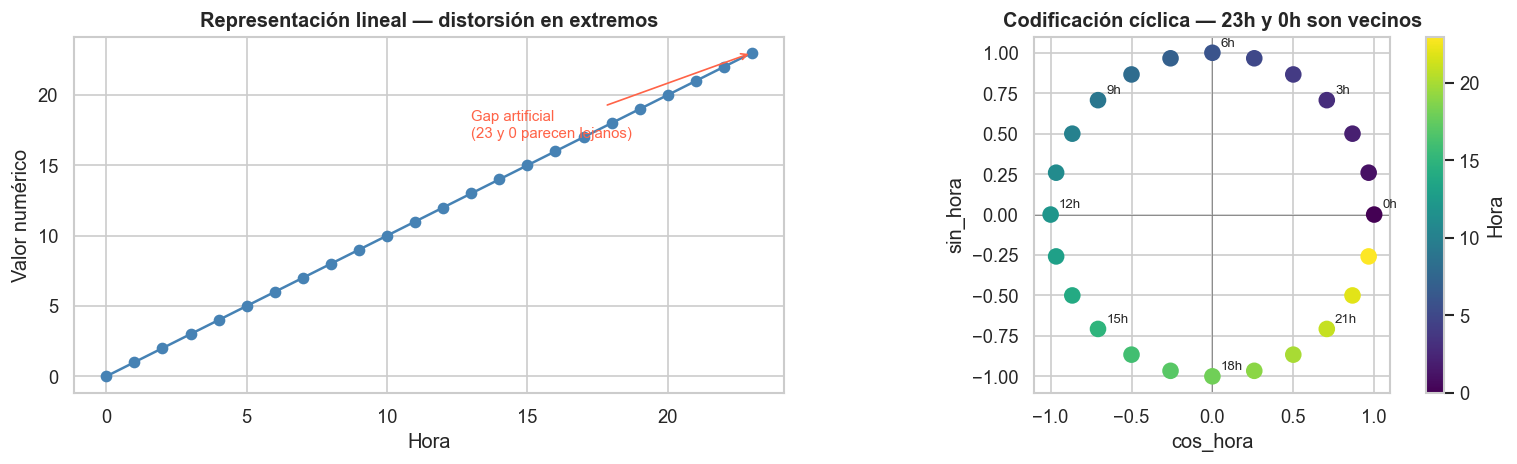

Columnas cíclicas creadas (8): ['sin_hora', 'cos_hora', 'sin_dia_sem', 'cos_dia_sem', 'sin_mes', 'cos_mes', 'sin_dia_anio', 'cos_dia_anio']


In [13]:
def agregar_features_ciclicas(df_input):
    """
    Codifica variables periódicas con sin/cos.
    Pares creados: hora (24h), dia_sem (7d), mes (12m), dia_anio (365d).
    """
    df_out = df_input.copy()
    ciclos = {'hora': 24, 'dia_sem': 7, 'mes': 12, 'dia_anio': 365}
    for col, periodo in ciclos.items():
        df_out[f'sin_{col}'] = np.sin(2 * np.pi * df_out[col] / periodo)
        df_out[f'cos_{col}'] = np.cos(2 * np.pi * df_out[col] / periodo)
    return df_out


df_feat = agregar_features_ciclicas(df_feat)

# --- Visualización: lineal vs cíclico ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

horas = np.arange(0, 24)
axes[0].plot(horas, horas, 'o-', color='steelblue')
axes[0].annotate('Gap artificial\n(23 y 0 parecen lejanos)',
    xy=(23, 23), xytext=(13, 17),
    arrowprops=dict(arrowstyle='->', color='tomato'), color='tomato', fontsize=9)
axes[0].set_title('Representación lineal — distorsión en extremos', fontweight='bold')
axes[0].set_xlabel('Hora'); axes[0].set_ylabel('Valor numérico')

sin_h = np.sin(2 * np.pi * horas / 24)
cos_h = np.cos(2 * np.pi * horas / 24)
sc = axes[1].scatter(cos_h, sin_h, c=horas, cmap='viridis', s=80, zorder=3)
for i in range(0, 24, 3):
    axes[1].annotate(f'{i}h', (cos_h[i], sin_h[i]),
                     textcoords='offset points', xytext=(5, 4), fontsize=8)
plt.colorbar(sc, ax=axes[1], label='Hora')
axes[1].set_title('Codificación cíclica — 23h y 0h son vecinos', fontweight='bold')
axes[1].set_xlabel('cos_hora'); axes[1].set_ylabel('sin_hora')
axes[1].set_aspect('equal')
axes[1].axhline(0, color='gray', lw=0.5)
axes[1].axvline(0, color='gray', lw=0.5)
plt.tight_layout(); plt.show()

cols_cic = [c for c in df_feat.columns if c.startswith(('sin_', 'cos_'))]
print(f'Columnas cíclicas creadas ({len(cols_cic)}): {cols_cic}')

### Variables históricas por barrio — sin *data leakage*

**Regla clave:** para cada fila en el momento **T**, la variable histórica se calcula usando **solo** observaciones con `TW < T`. Se logra ordenando el dataset por `TW` y aplicando `shift(1).expanding()` dentro de cada grupo. Las primeras filas de cada barrio (sin historial aún) reciben la media global como valor por defecto.

Variables creadas:
- `tasa_hist_barrio`: proporción histórica de horas con accidente en ese barrio.
- `tasa_hist_barrio_hora`: ídem, pero segmentado por hora del día (más granular).
- `acc_hist_acum`: conteo acumulado de accidentes en ese barrio hasta T.
- `comuna_barrio`: comuna asociada al barrio (desde `raw_accidentes`).

Calculando variables históricas...

Verificación anti-leakage:
  Media global del target:                    0.015075
  Barrios con primera fila = media global:    100.0% ✅


C:\Users\USER\AppData\Local\Temp\ipykernel_16872\918791238.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_feat, x='target', y=col, palette='Set2', ax=ax)
C:\Users\USER\AppData\Local\Temp\ipykernel_16872\918791238.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Sin accidente (0)', 'Con accidente (1)'])
C:\Users\USER\AppData\Local\Temp\ipykernel_16872\918791238.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_feat, x='target', y=col, palette='Set2', ax=ax)
C:\Users\USER\AppData\Local\Temp\ipykernel_16872\918791238.py:65: UserWarning: set_ticklabels() should 

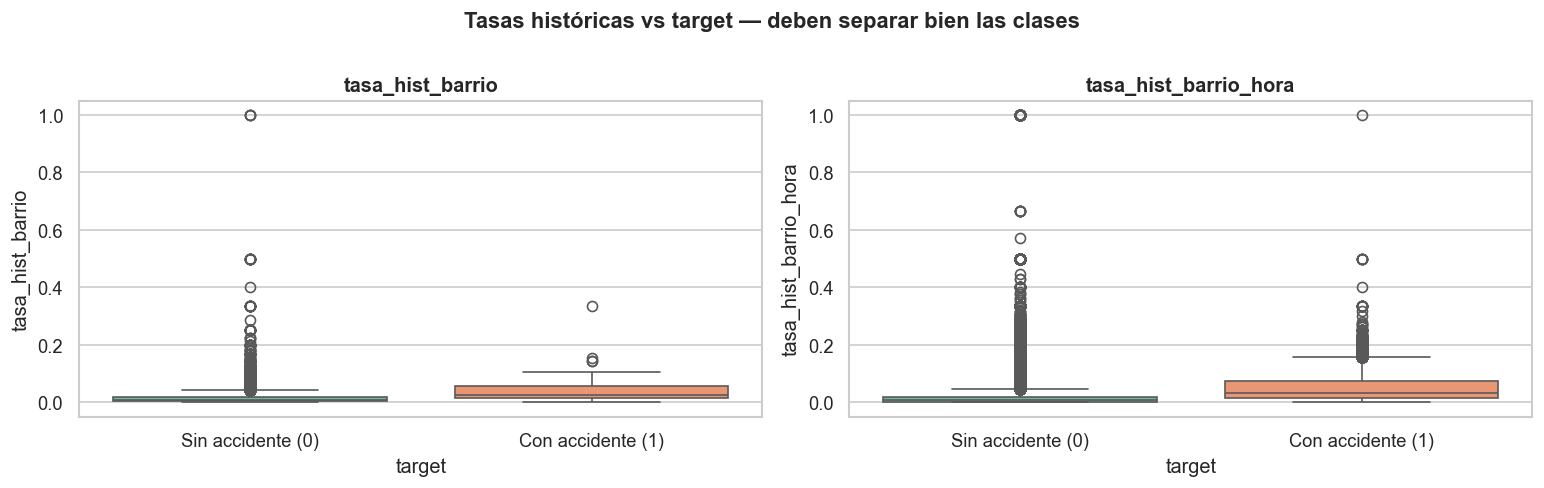


Comunas detectadas: 27


In [14]:
def agregar_features_historicas(df_input, raw_input):
    """
    Calcula variables históricas sin fuga de información temporal.

    Usa shift(1).expanding() sobre el dataset ordenado por TW, de modo
    que cada fila solo ve datos anteriores a su propio instante T.

    Nota de rendimiento: con ~8M filas puede tardar 1-2 min.
    Para pruebas rápidas: df_input.sample(frac=0.1, random_state=42)
    """
    # Ordenar cronológicamente — obligatorio para que shift(1) sea correcto
    df_out = df_input.sort_values('TW').reset_index(drop=True).copy()
    media_global = df_out['target'].mean()

    # 1. Tasa histórica de accidentalidad por barrio
    df_out['tasa_hist_barrio'] = (
        df_out.groupby('BARRIO')['target']
        .transform(lambda x: x.shift(1).expanding().mean())
        .fillna(media_global)   # sin historial → media global como prior
    )

    # 2. Conteo acumulado de accidentes por barrio
    df_out['acc_hist_acum'] = (
        df_out.groupby('BARRIO')['target']
        .transform(lambda x: x.shift(1).cumsum())
        .fillna(0)
    )

    # 3. Tasa histórica por barrio x hora del día (más granular)
    df_out['tasa_hist_barrio_hora'] = (
        df_out.groupby(['BARRIO', 'hora'])['target']
        .transform(lambda x: x.shift(1).expanding().mean())
        .fillna(media_global)
    )

    # 4. Comuna por barrio (desde raw_accidentes, sin leakage — es un atributo fijo)
    mapa_comuna = (
        raw_input.dropna(subset=['BARRIO', 'COMUNA'])
        .assign(BARRIO=lambda d: d['BARRIO'].str.strip().str.upper())
        .groupby('BARRIO')['COMUNA']
        .agg(lambda x: x.mode().iloc[0] if len(x) > 0 else None)
    )
    df_out['comuna'] = df_out['BARRIO'].map(mapa_comuna).fillna('DESCONOCIDA')

    return df_out


print('Calculando variables históricas...')
df_feat = agregar_features_historicas(df_feat, raw)

# --- Verificación anti-leakage ---
# La primera aparición de cada barrio DEBE tener tasa = media global
primera_fila = df_feat.groupby('BARRIO')['tasa_hist_barrio'].first()
media_global = df_feat['target'].mean()
pct_ok = (primera_fila.round(6) == round(media_global, 6)).mean() * 100
print(f'\nVerificación anti-leakage:')
print(f'  Media global del target:                    {media_global:.6f}')
print(f'  Barrios con primera fila = media global:    {pct_ok:.1f}% '
      f'{"✅" if pct_ok == 100 else "❌ REVISAR"}')

# --- Poder discriminante ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col in zip(axes, ['tasa_hist_barrio', 'tasa_hist_barrio_hora']):
    sns.boxplot(data=df_feat, x='target', y=col, palette='Set2', ax=ax)
    ax.set_xticklabels(['Sin accidente (0)', 'Con accidente (1)'])
    ax.set_title(col, fontweight='bold')
plt.suptitle('Tasas históricas vs target — deben separar bien las clases',
             fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

print(f'\nComunas detectadas: {df_feat["comuna"].nunique()}')

### Selección de variables climáticas

Basada en el EDA de la sección anterior:

| Variable | Justificación |
|---|---|
| `humidity` | Distribución diferente entre clases (boxplot EDA) |
| `precipIntensity`, `precipProbability` | Lluvia correlaciona con accidentalidad |
| `visibility` | Menor visibilidad → mayor riesgo |
| `windSpeed` | Viento afecta control del vehículo |
| `temperature`, `apparentTemperature` | Contexto térmico |
| `cloudCover`, `dewPoint`, `uvIndex` | Señales de condición meteorológica general |

Se excluyen `windBearing` (dirección del viento, poca relación causal directa) y `pressure` (no está en el esquema original de los datos).

### Codificación de variables categóricas

- **`BARRIO`, `summary`, `icon`:** *Frequency encoding*. One-hot generaría cientos de columnas esparsas; target encoding requiere recalcularse dentro de cada fold para evitar leakage. La frecuencia es un proxy seguro y captura cuán representada está cada categoría.
- **`periodo_dia`:** One-hot (solo 4 categorías, manejable).
- **`comuna`:** Frequency encoding (cardinalidad media).

> **Nota:** en el pipeline de modelado, los mapeos de frecuencia se recalcularán **solo sobre el conjunto de entrenamiento** antes de aplicarse a validación, para evitar leakage.

In [15]:
def codificar_categoricas(df_inout):
    """Modifica el dataframe IN-PLACE para evitar copias en memoria."""
    
    for col in ['BARRIO', 'summary', 'icon', 'comuna']:
        if col in df_inout.columns:
            freq = df_inout[col].value_counts(normalize=True)
            df_inout[f'{col}_freq'] = df_inout[col].map(freq).fillna(0).astype('float32')
            print(f'  {col:<10}: {df_inout[col].nunique():>4} categorías → {col}_freq creada')

    # One-hot manual in-place, dtype int8 (8x menos memoria que int64)
    if 'periodo_dia' in df_inout.columns:
        for cat in ['madrugada', 'manana', 'tarde', 'noche']:
            df_inout[f'periodo_{cat}'] = (df_inout['periodo_dia'] == cat).astype('int8')
        print(f'  periodo_dia → one-hot creado (int8)')

    return df_inout  # misma referencia, sin copia


print('Codificando variables categóricas:')
codificar_categoricas(df_feat)  # modifica df_feat directamente


print('Codificando variables categóricas:')
df_feat = codificar_categoricas(df_feat)

Codificando variables categóricas:
  BARRIO    :  319 categorías → BARRIO_freq creada
  summary   :   20 categorías → summary_freq creada
  icon      :    8 categorías → icon_freq creada
  comuna    :   27 categorías → comuna_freq creada
  periodo_dia → one-hot creado (int8)
Codificando variables categóricas:
  BARRIO    :  319 categorías → BARRIO_freq creada
  summary   :   20 categorías → summary_freq creada
  icon      :    8 categorías → icon_freq creada
  comuna    :   27 categorías → comuna_freq creada
  periodo_dia → one-hot creado (int8)


### Consolidación final — lista `FEATURES`

Se define la lista `FEATURES` con todas las variables del modelo, `TARGET` con la variable objetivo y `COLS_EXCLUIR` con columnas a descartar. Estas tres variables son el punto de entrada de la sección 4.4.

RESUMEN — INGENIERÍA DE CARACTERÍSTICAS
Dataset:           7,991,780 filas x 45 columnas
Features totales:         37
  Climáticas    : 10
  Temporales    : 7
  Cíclicas      : 8
  Históricas    : 3
  Codificadas   : 9

Verificando nulos...
⚠️  Features con nulos:
   temperature: 610
   apparentTemperature: 610
   humidity: 915
   precipIntensity: 547401
   precipProbability: 547401
   windSpeed: 32793
   cloudCover: 7950
   visibility: 4290
   uvIndex: 4280
   dewPoint: 305

Calculando correlaciones...


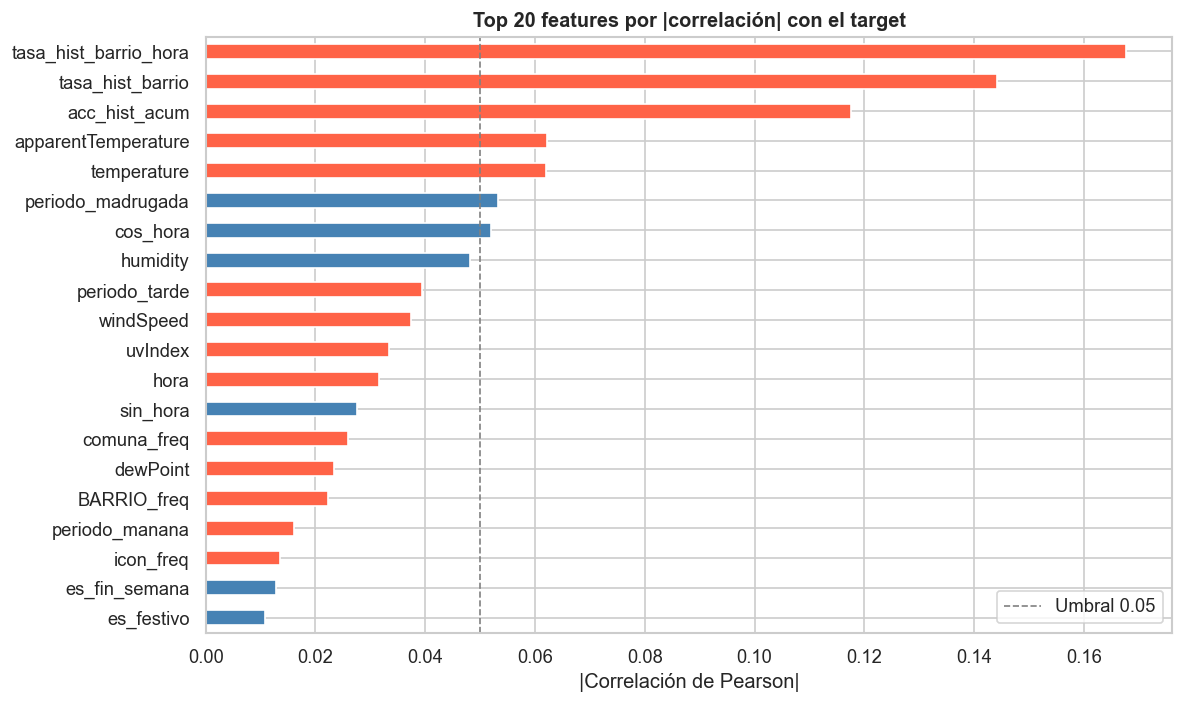


→ FEATURES, TARGET y COLS_EXCLUIR listos para la sección 4.4.


In [16]:
def definir_columnas_modelo(df_input):
    """
    Devuelve FEATURES (lista), TARGET (str) y COLS_EXCLUIR (lista).
    Solo incluye columnas que existen en df_input.
    """
    vars_clima = [v for v in [
        'temperature', 'apparentTemperature', 'humidity',
        'precipIntensity', 'precipProbability', 'windSpeed',
        'cloudCover', 'visibility', 'uvIndex', 'dewPoint'
    ] if v in df_input.columns]

    vars_temp     = ['hora', 'dia', 'mes', 'dia_sem', 'dia_anio',
                     'es_fin_semana', 'es_festivo']
    vars_ciclicas = [c for c in df_input.columns if c.startswith(('sin_', 'cos_'))]
    vars_hist     = ['tasa_hist_barrio', 'tasa_hist_barrio_hora', 'acc_hist_acum']
    vars_enc      = ([c for c in df_input.columns if c.endswith('_freq')]
                     + [c for c in df_input.columns if c.startswith('periodo_')])

    features = vars_clima + vars_temp + vars_ciclicas + vars_hist + vars_enc
    features = [c for c in features if c in df_input.columns]

    cols_excluir = ['TW', 'BARRIO', 'summary', 'icon', 'comuna',
                'Lat', 'Lon', 'Dia_sem', 'anio', 'windBearing', 'periodo_dia']

    return features, 'target', cols_excluir


FEATURES, TARGET, COLS_EXCLUIR = definir_columnas_modelo(df_feat)

# --- Resumen por grupo ---
grupos = {
    'Climáticas' : ['temperature','apparentTemperature','humidity','precipIntensity',
                    'precipProbability','windSpeed','cloudCover','visibility','uvIndex','dewPoint'],
    'Temporales' : ['hora','dia','mes','dia_sem','dia_anio','es_fin_semana','es_festivo'],
    'Cíclicas'   : [c for c in FEATURES if c.startswith(('sin_','cos_'))],
    'Históricas' : ['tasa_hist_barrio','tasa_hist_barrio_hora','acc_hist_acum'],
    'Codificadas': [c for c in FEATURES if c.endswith('_freq') or c.startswith('periodo_')],
}

print('=' * 50)
print('RESUMEN — INGENIERÍA DE CARACTERÍSTICAS')
print('=' * 50)
print(f'Dataset:          {df_feat.shape[0]:>10,} filas x {df_feat.shape[1]} columnas')
print(f'Features totales: {len(FEATURES):>10}')
for grp, cols in grupos.items():
    n = sum(1 for c in cols if c in FEATURES)
    print(f'  {grp:<14}: {n}')

# Verificar nulos columna por columna — sin crear subset del dataframe
print('\nVerificando nulos...')
nulos = {col: df_feat[col].isnull().sum() for col in FEATURES}
nulos = {k: v for k, v in nulos.items() if v > 0}
if nulos:
    print('⚠️  Features con nulos:')
    for k, v in nulos.items():
        print(f'   {k}: {v}')
else:
    print(f'✅ Sin nulos en las {len(FEATURES)} features del modelo.')

# Correlación columna por columna — sin materializar df_feat[FEATURES]
print('\nCalculando correlaciones...')
target_vals = df_feat[TARGET]
corr_vals = {}
for col in FEATURES:
    if df_feat[col].dtype.kind in 'fiu':  # solo numéricas
        corr_vals[col] = df_feat[col].corr(target_vals)

corr_series = pd.Series(corr_vals)
top_corr = corr_series.abs().sort_values(ascending=False).head(20)
colores  = ['tomato' if corr_series[c] > 0 else 'steelblue' for c in top_corr.index]

plt.figure(figsize=(10, 6))
top_corr.sort_values().plot(kind='barh', color=colores[::-1], edgecolor='white')
plt.title('Top 20 features por |correlación| con el target', fontweight='bold')
plt.xlabel('|Correlación de Pearson|')
plt.axvline(0.05, color='gray', linestyle='--', linewidth=1, label='Umbral 0.05')
plt.legend()
plt.tight_layout(); plt.show()

print('\n→ FEATURES, TARGET y COLS_EXCLUIR listos para la sección 4.4.')